# Individual Assignment I — Machine Learning Foundations
## Data Preparation Pipeline for Bank Marketing Dataset

**Course:** AI: Machine Learning Foundation
**Dataset:** UCI Bank Marketing — `bank-additional.csv`

**GitHub repository:** https://github.com/hamzamadi1/ML-fundamentals-2026

**Objective:**
The goal is to design a disciplined, leakage-free data preparation pipeline to predict whether a client subscribes to a term deposit (`y`). The emphasis is not on maximizing performance, but on correct task ordering, justified preprocessing decisions, and clean ML pipeline design.

This notebook follows:
1. Identifying the prediction target
2. Data loading and EDA
3. Missing values (explicit + implicit) and sentinel handling
4. Task ordering justification
5. Stratified train/validation/test split
6. Feature selection (low variance + correlation + conceptual)
7. Encoding categorical variables
8. Scaling numerical variables
9. Class imbalance handling (training only)
10. Logistic Regression sanity check + evaluation metrics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
DATA_PATH = "bank-additional.csv"
df = pd.read_csv(DATA_PATH, sep=";")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [3]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
df.info()
df.describe(include="all").T.head(25)

Shape: (4119, 21)

Columns:
 ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,4119.0,NaN,NaN,NaN,40.11362,10.313362,18.0,32.0,38.0,47.0,88.0
job,4119,12,admin.,1012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,4119,4,married,2509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,4119,8,university.degree,1264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,4119,3,no,3315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,4119,3,yes,2175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,4119,3,no,3349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,4119,2,cellular,2652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,4119,10,may,1378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,4119,5,thu,860,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Identifying the Prediction Target

The target variable for this assignment is `y`, which indicates whether the client subscribed to a term deposit (`yes`/`no`). This matches the marketing campaign objective described in the dataset documentation.

Two variables that could superficially appear as “targets” but should not be treated as the prediction objective are:
- `duration`: call duration is known only after the call ends and is not the subscription outcome.
- `campaign`: number of contacts during the campaign is a process variable, not the final subscription decision.

In [4]:
df["y"].value_counts()
df["y"].value_counts(normalize=True)

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

## Data Loading and Exploration (EDA)

The goal of EDA is to understand data types, target imbalance, missingness patterns (explicit and implicit), and potential issues for modeling (e.g., skewness, sentinel values, availability at prediction time). Visualizations are selected to support specific observations.

In [5]:
na_counts = df.isna().sum().sort_values(ascending=False)
na_counts[na_counts > 0] if (na_counts > 0).any() else "No NaNs detected."

'No NaNs detected.'

In [6]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns

unknown_counts = {}
for c in cat_cols:
    unknown_counts[c] = (df[c].astype(str).str.lower() == "unknown").sum()

unknown_counts = pd.Series(unknown_counts).sort_values(ascending=False)
unknown_counts[unknown_counts > 0]

default      803
education    167
housing      105
loan         105
job           39
marital       11
dtype: int64

### Handling Implicit Missing Values in Categorical Variables

The dataset contains no explicit missing values (`NaN`), but several categorical variables include the category `"unknown"`, which functions as implicit missingness.

Instead of converting `"unknown"` to `NaN` and imputing, it is retained as a separate category. This preserves potentially informative missingness (e.g., undisclosed default status) and allows one-hot encoding to model it explicitly without injecting assumptions through imputation.

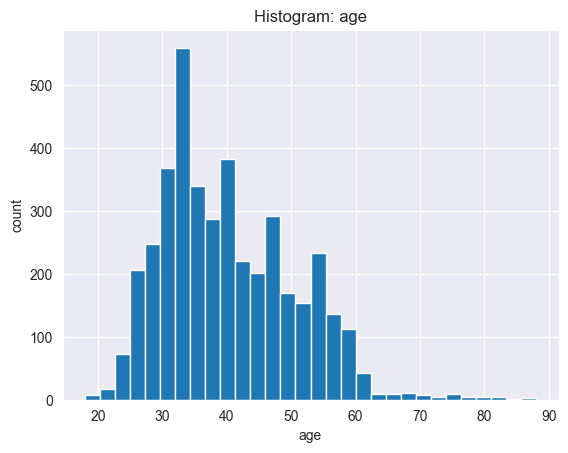

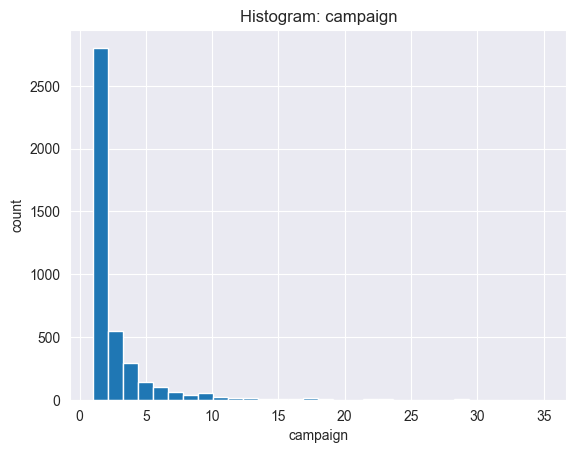

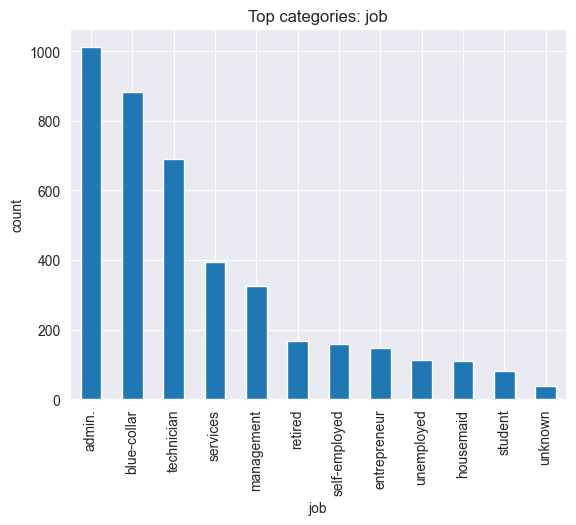

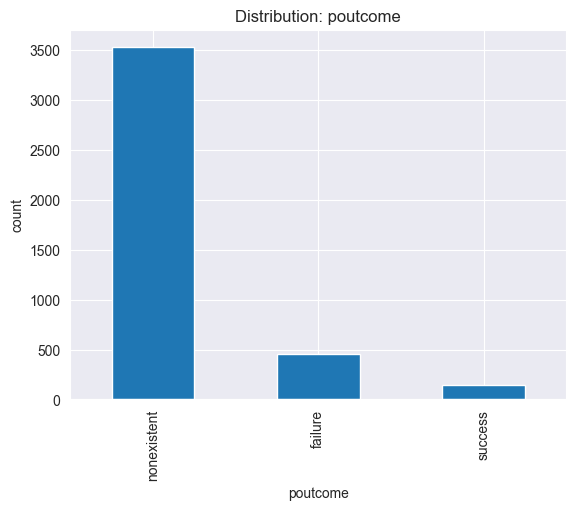

In [7]:
import matplotlib.pyplot as plt

# --- 2 numerical variables ---
plt.figure()
df["age"].hist(bins=30)
plt.title("Histogram: age")
plt.xlabel("age"); plt.ylabel("count")
plt.show()

plt.figure()
df["campaign"].hist(bins=30)
plt.title("Histogram: campaign")
plt.xlabel("campaign"); plt.ylabel("count")
plt.show()

# --- 2 categorical variables ---
plt.figure()
df["job"].value_counts().head(15).plot(kind="bar")
plt.title("Top categories: job")
plt.xlabel("job"); plt.ylabel("count")
plt.show()

plt.figure()
df["poutcome"].value_counts().plot(kind="bar")
plt.title("Distribution: poutcome")
plt.xlabel("poutcome"); plt.ylabel("count")
plt.show()

**EDA observations (examples):**
- The target is imbalanced (~11% `yes`), so accuracy alone can be misleading.
- `campaign` is right-skewed, suggesting most clients are contacted few times while a minority is contacted many times.
- Several categorical fields contain `"unknown"`, indicating implicit missingness that may carry predictive signal.

In [8]:
df["pdays"].value_counts().head(10), (df["pdays"] == 999).mean()

(pdays
 999    3959
 3        52
 6        42
 4        14
 7        10
 10        8
 12        5
 5         4
 2         4
 1         3
 Name: count, dtype: int64,
 np.float64(0.9611556202961884))

### Handling Sentinel Values in `pdays`

A large fraction of observations have `pdays = 999`. In this dataset, `999` is a sentinel code meaning the client was never previously contacted, not a real number of days.

Treating `999` as numeric would distort scaling and interpretation. Therefore the information is split into:
1) a binary indicator (`previously_contacted`), and
2) a numeric `pdays` value only when meaningful, with sentinel replaced by `NaN` for imputation later.

In [9]:
df["previously_contacted"] = (df["pdays"] != 999).astype(int)
df.loc[df["pdays"] == 999, "pdays"] = np.nan

## Task Ordering and Leakage Control

**Correct order (high level):**
1. Identify target and clarify prediction-time constraints.
2. Load data + EDA (no parameter learning).
3. Conceptual feature decisions (e.g., remove variables unavailable at prediction time).
4. Split into train/validation/test with stratification.
5. Fit preprocessing on training only (imputation, feature selection, encoding, scaling).
6. Apply resampling on training only (part of training procedure).
7. Train Logistic Regression.
8. Evaluate on validation; keep test untouched.

**Incorrect ordering example:**
If scaling/encoding/imputation/resampling is performed before splitting, statistics or synthetic samples derived from validation/test contaminate training. This data leakage inflates evaluation metrics and does not reflect real deployment.

## Data Splitting (Train / Validation / Test)

The dataset is split into three subsets:
- **Training set (60%)**: used to fit preprocessing steps and train the model.
- **Validation set (20%)**: used to evaluate the model during development.
- **Test set (20%)**: held out for a final unbiased check (kept untouched during design decisions).

A **stratified split** is performed with respect to the target variable `y` because the dataset is imbalanced (~11% positive class). Stratification preserves class proportions across splits, preventing unstable evaluation due to accidental class under-representation in validation/test.

The split must occur **before** any step that learns parameters from data (imputation, scaling, encoding, resampling, feature selection). Performing those steps before splitting would leak information from validation/test into training and produce overly optimistic performance estimates.

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["y"])
y = df["y"].map({"no": 0, "yes": 1})

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nClass distribution (proportions):")
print("Train:", y_train.value_counts(normalize=True))
print("Val:  ", y_val.value_counts(normalize=True))
print("Test: ", y_test.value_counts(normalize=True))

Train shape: (2471, 21)
Validation shape: (824, 21)
Test shape: (824, 21)

Class distribution (proportions):
Train: y
0    0.890328
1    0.109672
Name: proportion, dtype: float64
Val:   y
0    0.890777
1    0.109223
Name: proportion, dtype: float64
Test:  y
0    0.890777
1    0.109223
Name: proportion, dtype: float64


## Conceptual Feature Removal: `duration`

`duration` is the length of the phone call. If the goal is to predict subscription using information available at the time of contact, `duration` is not available at prediction time (it is only known after the call ends).

Including `duration` would introduce temporal (conceptual) leakage and inflate performance. Therefore, `duration` is removed.

In [11]:
for _X in (X_train, X_val, X_test):
    pass

X_train = X_train.drop(columns=["duration"])
X_val = X_val.drop(columns=["duration"])
X_test = X_test.drop(columns=["duration"])

## Feature Selection: Low Variance (Training Set Only)

Features with near-zero variance provide no discriminatory information. This check is performed on the training set only to avoid leakage. If a feature has zero variance in training, it is removed from all splits.

In [12]:
numeric_features_tmp = X_train.select_dtypes(exclude=["object", "string"]).columns.tolist()
var_series = X_train[numeric_features_tmp].var().sort_values()
var_series

previously_contacted       0.039962
previous                   0.320324
cons.price.idx             0.343885
emp.var.rate               2.457339
euribor3m                  3.038669
campaign                   7.183459
pdays                     15.788311
cons.conf.idx             21.749100
age                      106.440729
nr.employed             5481.162130
dtype: float64

In [13]:
# Example: if previously_contacted ends up zero-variance in your train split
if "previously_contacted" in X_train.columns and X_train["previously_contacted"].var() == 0:
    X_train = X_train.drop(columns=["previously_contacted"])
    X_val = X_val.drop(columns=["previously_contacted"])
    X_test = X_test.drop(columns=["previously_contacted"])

## Feature Selection: Highly Correlated Numerical Features (Training Set Only)

Highly correlated numerical features can cause multicollinearity in Logistic Regression, making coefficients unstable and reducing interpretability.

A threshold of **|r| > 0.85** is used to flag highly correlated pairs. When redundancy is detected, one feature may be removed based on interpretability and redundancy considerations.

This analysis is performed on the training set only to avoid leakage.

Although multicollinearity does not necessarily reduce predictive performance, it destabilizes coefficient estimates and reduces interpretability in linear models.

In [14]:
corr_numeric = X_train.select_dtypes(exclude=["object", "string"]).corr()
corr_numeric

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,previously_contacted
age,1.000000,-0.009352,-0.167473,0.033627,-0.010362,0.008347,0.117791,-0.003252,-0.033675,0.051888
campaign,-0.009352,1.000000,0.204584,-0.104890,0.192923,0.145004,0.017746,0.176367,0.176557,-0.070922
pdays,-0.167473,0.204584,1.000000,0.037797,0.162344,0.275916,-0.134952,-0.136624,-0.283286,NaN
previous,0.033627,-0.104890,0.037797,1.000000,-0.428931,-0.183358,-0.021387,-0.469319,-0.520717,0.601133
emp.var.rate,-0.010362,0.192923,0.162344,-0.428931,1.000000,0.757662,0.178391,0.970013,0.896018,-0.282477
cons.price.idx,0.008347,0.145004,0.275916,-0.183358,0.757662,1.000000,0.029163,0.656884,0.470515,-0.066681
cons.conf.idx,0.117791,0.017746,-0.134952,-0.021387,0.178391,0.029163,1.000000,0.264169,0.096543,0.108609
euribor3m,-0.003252,0.176367,-0.136624,-0.469319,0.970013,0.656884,0.264169,1.000000,0.941699,-0.312431
nr.employed,-0.033675,0.176557,-0.283286,-0.520717,0.896018,0.470515,0.096543,0.941699,1.000000,-0.394505
previously_contacted,0.051888,-0.070922,NaN,0.601133,-0.282477,-0.066681,0.108609,-0.312431,-0.394505,1.000000


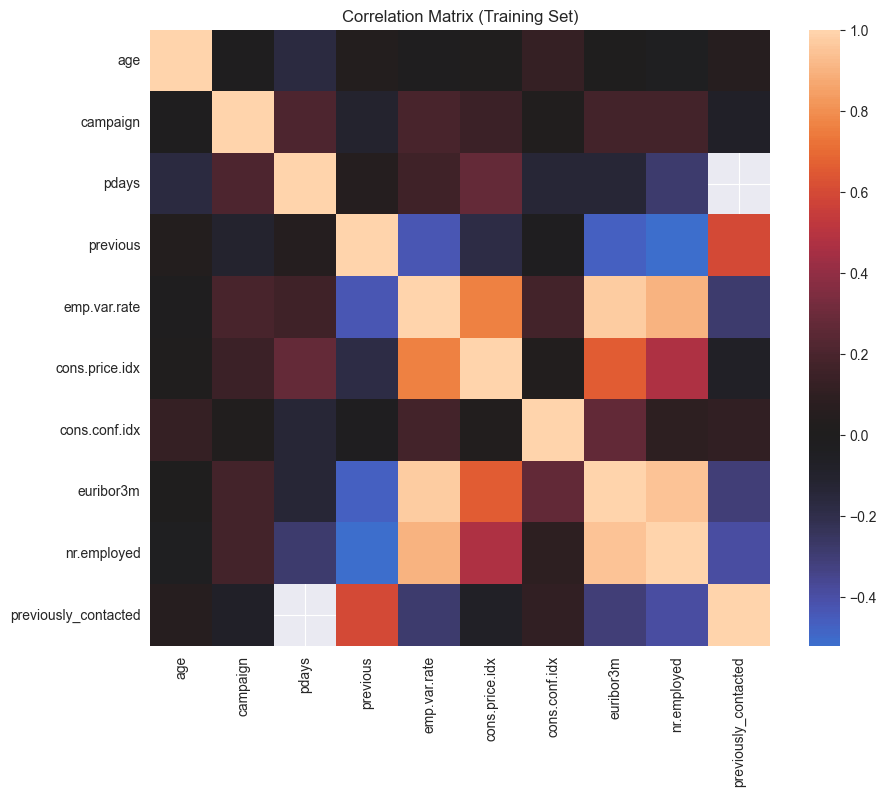

In [15]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(corr_numeric, center=0)
plt.title("Correlation Matrix (Training Set)")
plt.show()

In [16]:
if "nr.employed" in X_train.columns:
    X_train = X_train.drop(columns=["nr.employed"])
    X_val = X_val.drop(columns=["nr.employed"])
    X_test = X_test.drop(columns=["nr.employed"])

## Encoding Categorical Variables

Categorical variables include nominal attributes such as `job`, `marital`, `contact`, `month`, `day_of_week`, and `poutcome`. `education` could be treated as ordinal, but its ordering can be ambiguous; therefore one-hot encoding is used for consistency and to avoid imposing artificial order.

**One-hot encoding** is chosen because it allows Logistic Regression to assign independent weights to categories without assuming an order.

**Effects:**
- Dimensionality increases (one feature per category).
- Coefficients become interpretable as category effects relative to a baseline.
- Linear decision boundaries in the transformed space become more expressive due to category-specific offsets.

Encoders must be fit on the training set only to avoid leakage (learning categories from validation/test).

## Feature Scaling

Numerical variables are standardized using `StandardScaler` (mean 0, variance 1).

Scaling is important for Logistic Regression because it:
- improves gradient-based optimization stability,
- makes coefficient magnitudes comparable,
- ensures regularization penalties are applied fairly across features.

Scaling parameters are learned from the training set only to prevent leakage.

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_features = X_train.select_dtypes(exclude=["object", "string"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Categorical:", categorical_features)
print("Numeric:", numeric_features)

Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'previously_contacted']


## Addressing Class Imbalance

The positive class (`y=1`) is a minority (~11%). In imbalanced settings, accuracy can be misleading because predicting the majority class yields a strong baseline.

Resampling is a training-time procedure and must be applied to the training set only. If oversampling were applied before splitting, duplicated/synthetic samples could leak into validation/test, inflating evaluation metrics.

A random oversampling strategy is used here as a simple, defensible approach.

Accuracy is misleading because predicting the majority class already yields ~89% accuracy.

In [18]:
print("Train class counts:\n", y_train.value_counts())
print("\nTrain class proportions:\n", y_train.value_counts(normalize=True))

Train class counts:
 y
0    2200
1     271
Name: count, dtype: int64

Train class proportions:
 y
0    0.890328
1    0.109672
Name: proportion, dtype: float64


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

sampler = RandomOverSampler(random_state=42)
clf = LogisticRegression(max_iter=2000)

pipe = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("resample", sampler),
    ("clf", clf)
])

pipe.fit(X_train, y_train)

y_val_pred = pipe.predict(X_val)

acc = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, zero_division=0)
rec = recall_score(y_val, y_val_pred, zero_division=0)

print("Validation Metrics:")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)

Validation Metrics:
Accuracy : 0.8300970873786407
Precision: 0.34177215189873417
Recall   : 0.6


Zero Rule Accuracy: 0.8907766990291263


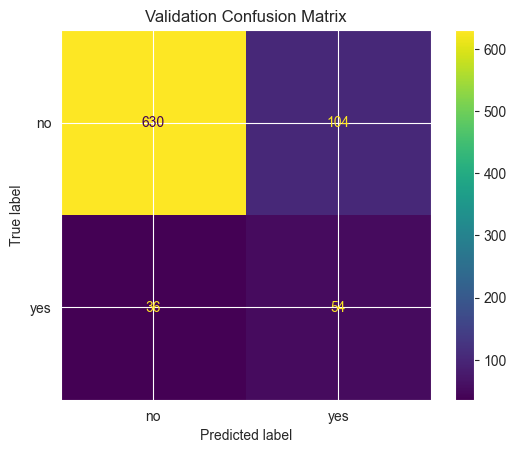

In [20]:
majority_class = y_train.value_counts().idxmax()
y_val_zero = np.full_like(y_val, fill_value=majority_class)
acc_zero = accuracy_score(y_val, y_val_zero)
print("Zero Rule Accuracy:", acc_zero)

cm = confusion_matrix(y_val, y_val_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no", "yes"])
disp.plot()
plt.title("Validation Confusion Matrix")
plt.show()

## Model Evaluation and Baseline Comparison

The Zero Rule baseline (always predicting the majority class) achieves high accuracy because the dataset is imbalanced. However, it fails to identify any positive cases, resulting in zero recall for subscribers.

After resampling and training Logistic Regression, accuracy decreases (expected trade-off), while recall for the positive class improves substantially. This illustrates why accuracy alone is misleading in imbalanced classification and why precision/recall provide a more meaningful assessment.

## Reproducibility Check

This notebook is intended to run from top to bottom using **Restart Kernel and Run All** without errors. All transformations that learn parameters (imputation, encoding, scaling, feature selection, resampling) are fitted on the training set only to avoid data leakage.